<a href="https://colab.research.google.com/github/Varsh555/ML2_lab/blob/main/ml2p4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


EXAMPLE 1: <Young, High, Yes, Good, High> -> Yes

Type: POSITIVE

Specific Boundary S:
    <Young, High, Yes, Good, High>

General Boundary G:
    <?, ?, ?, ?, ?>

EXAMPLE 2: <Middle, Medium, Yes, Excellent, High> -> Yes

Type: POSITIVE

Specific Boundary S:
    <?, ?, Yes, ?, High>

General Boundary G:
    <?, ?, ?, ?, ?>

EXAMPLE 3: <Senior, Low, Yes, Good, High> -> Yes

Type: POSITIVE

Specific Boundary S:
    <?, ?, Yes, ?, High>

General Boundary G:
    <?, ?, ?, ?, ?>

EXAMPLE 4: <Young, Medium, No, Good, High> -> No

Type: NEGATIVE

Specific Boundary S:
    <?, ?, Yes, ?, High>

General Boundary G:
    <?, ?, Yes, ?, ?>

EXAMPLE 5: <Middle, High, No, Excellent, High> -> No

Type: NEGATIVE

Specific Boundary S:
    <?, ?, Yes, ?, High>

General Boundary G:
    <?, ?, Yes, ?, ?>

EXAMPLE 6: <Senior, Medium, Yes, Poor, Low> -> No

Type: NEGATIVE

Specific Boundary S:
    <?, ?, Yes, ?, High>

General Boundary G:
    <?, ?, Yes, ?, High>

EXAMPLE 7: <Young, Low, No, Good, Low> -> N

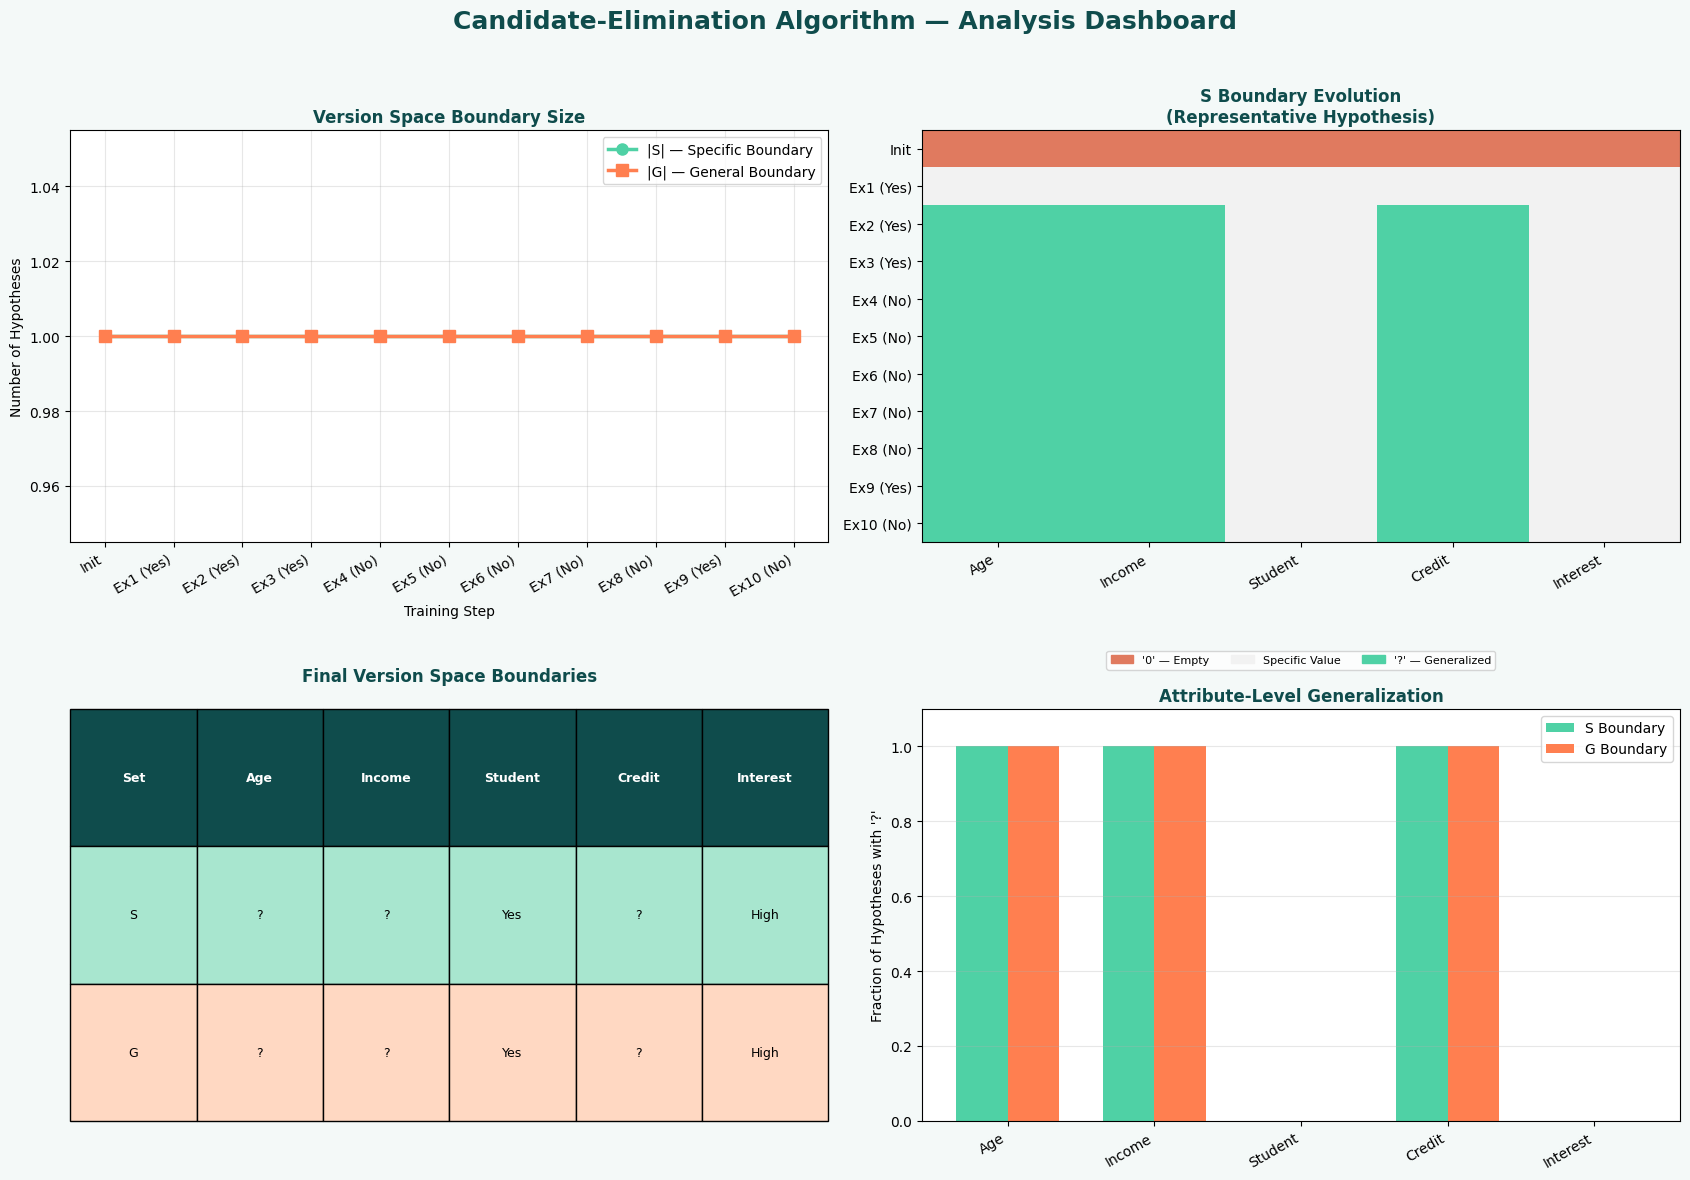


Visualization saved as:
candidate_elimination_analysis.png


In [6]:


"""
============================================================
CANDIDATE-ELIMINATION ALGORITHM
============================================================

Dataset: BuyLaptop

The program demonstrates:

1. Training examples
2. Specific boundary S
3. General boundary G
4. Candidate-Elimination processing
5. Version-space evolution
6. Final S and G boundaries
7. Visualization of the learning process
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


# =========================================================
# 1. DATASET
# =========================================================

attributes = [
    "Age",
    "Income",
    "Student",
    "Credit",
    "Interest"
]

target = "BuyLaptop"


# ---------------------------------------------------------
# 10 TRAINING EXAMPLES
# ---------------------------------------------------------
#
# Intended concept:
#
# Student = Yes AND Interest = High
#                  -> BuyLaptop = Yes
#
# Otherwise:
#                  -> BuyLaptop = No
#
# ---------------------------------------------------------

data = [

    {
        "Age": "Young",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Middle",
        "Income": "Medium",
        "Student": "Yes",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Senior",
        "Income": "Low",
        "Student": "Yes",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Young",
        "Income": "Medium",
        "Student": "No",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "No"
    },

    {
        "Age": "Middle",
        "Income": "High",
        "Student": "No",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "No"
    },

    {
        "Age": "Senior",
        "Income": "Medium",
        "Student": "Yes",
        "Credit": "Poor",
        "Interest": "Low",
        "BuyLaptop": "No"
    },

    {
        "Age": "Young",
        "Income": "Low",
        "Student": "No",
        "Credit": "Good",
        "Interest": "Low",
        "BuyLaptop": "No"
    },

    {
        "Age": "Middle",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Poor",
        "Interest": "Medium",
        "BuyLaptop": "No"
    },

    {
        "Age": "Senior",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Young",
        "Income": "Medium",
        "Student": "No",
        "Credit": "Poor",
        "Interest": "Medium",
        "BuyLaptop": "No"
    }
]


# =========================================================
# 2. PREPARE X AND y
# =========================================================

X = [
    [row[attr] for attr in attributes]
    for row in data
]

y = [
    row[target]
    for row in data
]

n_attributes = len(attributes)


# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================

def more_general(h1, h2):
    """
    Returns True if h1 is more general than or equal to h2.

    Symbols:

        '?' = any value
        '0' = no value / most specific
    """

    for x, y_value in zip(h1, h2):

        # '?' is more general than any value
        if x == "?":
            continue

        # '0' is the most specific value
        if x == "0":

            if y_value == "0":
                continue

            return False

        # If h2 is '0', h1 is more general
        if y_value == "0":
            continue

        # Specific values must be equal
        if x != y_value:
            return False

    return True


def consistent(h, instance):
    """
    Returns True if hypothesis h covers the instance.
    """

    for hx, ix in zip(h, instance):

        # '?' matches everything
        if hx == "?":
            continue

        # '0' matches nothing
        if hx == "0":
            return False

        # Specific value must match
        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """
    Generate minimal generalization of h
    required to cover a positive example.
    """

    new_h = list(h)

    for i in range(len(h)):

        # If attribute is empty,
        # replace it with the instance value.
        if h[i] == "0":

            new_h[i] = instance[i]

        # If attribute has a different value,
        # generalize it to '?'.
        elif h[i] != instance[i]:

            new_h[i] = "?"

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """
    Generate minimal specializations of h
    that exclude a negative example.

    Only '?' attributes can be specialized.
    """

    results = []

    for i in range(len(h)):

        if h[i] == "?":

            for value in domains[i]:

                if value != instance[i]:

                    new_h = list(h)

                    new_h[i] = value

                    results.append(
                        tuple(new_h)
                    )

    return results


def remove_more_general(hypotheses):
    """
    Used for S.

    Remove hypotheses that are more general
    than another hypothesis.

    The result contains the maximally
    specific hypotheses.
    """

    result = []

    for h in hypotheses:

        more_general_than_other = False

        for h2 in hypotheses:

            if h != h2 and more_general(h, h2):

                more_general_than_other = True
                break

        if not more_general_than_other:

            result.append(h)

    return result


def remove_less_general(hypotheses):
    """
    Used for G.

    Remove hypotheses that are less general
    than another hypothesis.

    The result contains the maximally
    general hypotheses.
    """

    result = []

    for h in hypotheses:

        less_general_than_other = False

        for h2 in hypotheses:

            if h != h2 and more_general(h2, h):

                less_general_than_other = True
                break

        if not less_general_than_other:

            result.append(h)

    return result


def hypothesis_string(h):
    """
    Convert a hypothesis tuple into readable form.
    """

    return "<" + ", ".join(h) + ">"


# =========================================================
# 4. CANDIDATE-ELIMINATION ALGORITHM
# =========================================================

def candidate_elimination(X, y, attributes):

    # -----------------------------------------------------
    # Find possible values for every attribute
    # -----------------------------------------------------

    domains = [
        sorted(
            set(
                row[i]
                for row in X
            )
        )
        for i in range(len(attributes))
    ]

    # -----------------------------------------------------
    # INITIAL SPECIFIC BOUNDARY
    # -----------------------------------------------------

    S = [
        tuple(
            ["0"] * n_attributes
        )
    ]

    # -----------------------------------------------------
    # INITIAL GENERAL BOUNDARY
    # -----------------------------------------------------

    G = [
        tuple(
            ["?"] * n_attributes
        )
    ]

    # -----------------------------------------------------
    # Store history for visualization
    # -----------------------------------------------------

    history = {

        "S_sizes": [len(S)],

        "G_sizes": [len(G)],

        "S_sets": [list(S)],

        "G_sets": [list(G)],

        "labels": ["Init"]
    }


    # =====================================================
    # PROCESS TRAINING EXAMPLES
    # =====================================================

    for idx, (instance, label) in enumerate(
        zip(X, y)
    ):

        instance = tuple(instance)

        print()
        print("=" * 70)

        print(
            f"EXAMPLE {idx + 1}: "
            f"{hypothesis_string(instance)} "
            f"-> {label}"
        )

        print("=" * 70)


        # =================================================
        # POSITIVE EXAMPLE
        # =================================================

        if label == "Yes":

            print("\nType: POSITIVE")

            # -------------------------------------------------
            # Remove G hypotheses that don't cover the example
            # -------------------------------------------------

            G = [
                g
                for g in G
                if consistent(g, instance)
            ]

            new_S = []

            # -------------------------------------------------
            # Process every S hypothesis
            # -------------------------------------------------

            for s in S:

                # If S already covers positive example,
                # keep it.
                if consistent(s, instance):

                    new_S.append(s)

                else:

                    # Otherwise generalize S
                    generalizations = (
                        min_generalizations(
                            s,
                            instance
                        )
                    )

                    for h in generalizations:

                        # Keep only hypotheses that are
                        # more specific than some G hypothesis.
                        if any(
                            more_general(g, h)
                            for g in G
                        ):

                            new_S.append(h)

            # Remove duplicates
            S = list(set(new_S))

            # Remove hypotheses that are too general
            S = remove_more_general(S)


        # =================================================
        # NEGATIVE EXAMPLE
        # =================================================

        else:

            print("\nType: NEGATIVE")

            # -------------------------------------------------
            # Remove S hypotheses that cover negative example
            # -------------------------------------------------

            S = [
                s
                for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            # -------------------------------------------------
            # Process every G hypothesis
            # -------------------------------------------------

            for g in G:

                # If G already excludes negative example,
                # keep it.
                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    # Otherwise specialize G
                    specializations = (
                        min_specializations(
                            g,
                            domains,
                            instance
                        )
                    )

                    for h in specializations:

                        # Keep h only if it is more general
                        # than at least one S hypothesis.
                        if any(
                            more_general(h, s)
                            for s in S
                        ):

                            new_G.append(h)

            # Remove duplicates
            G = list(set(new_G))

            # Remove hypotheses that are too specific
            G = remove_less_general(G)


        # =================================================
        # REMOVE DUPLICATES AGAIN
        # =================================================

        S = list(set(S))
        G = list(set(G))


        # =================================================
        # STORE HISTORY
        # =================================================

        history["S_sizes"].append(
            len(S)
        )

        history["G_sizes"].append(
            len(G)
        )

        history["S_sets"].append(
            list(S)
        )

        history["G_sets"].append(
            list(G)
        )

        history["labels"].append(
            f"Ex{idx + 1} ({label})"
        )


        # =================================================
        # PRINT CURRENT S
        # =================================================

        print("\nSpecific Boundary S:")

        if S:

            for s in S:

                print(
                    "   ",
                    hypothesis_string(s)
                )

        else:

            print("    EMPTY")


        # =================================================
        # PRINT CURRENT G
        # =================================================

        print("\nGeneral Boundary G:")

        if G:

            for g in G:

                print(
                    "   ",
                    hypothesis_string(g)
                )

        else:

            print("    EMPTY")


        # =================================================
        # CHECK VERSION SPACE
        # =================================================

        if not S or not G:

            print()
            print(
                "WARNING: Version space boundary has become empty."
            )


    return S, G, history


# =========================================================
# 5. RUN ALGORITHM
# =========================================================

S_final, G_final, history = candidate_elimination(
    X,
    y,
    attributes
)


# =========================================================
# 6. FINAL RESULTS
# =========================================================

print()
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)


print("\nFINAL SPECIFIC BOUNDARY (S):")

if S_final:

    for s in S_final:

        print(
            "   ",
            hypothesis_string(s)
        )

else:

    print("    EMPTY")


print("\nFINAL GENERAL BOUNDARY (G):")

if G_final:

    for g in G_final:

        print(
            "   ",
            hypothesis_string(g)
        )

else:

    print("    EMPTY")


# =========================================================
# 7. VISUALIZATION COLORS
# =========================================================

COL_TEAL = "#0f4c4c"
COL_MINT = "#4fd1a5"
COL_LIGHT = "#a8e6cf"
COL_ACCENT = "#ff7f50"
COL_BG = "#f4f9f8"


# =========================================================
# 8. SPECIFICITY SCORE
# =========================================================

def specificity_score(h):

    """
    Numeric representation:

        -1 = '0'  (empty)
         0 = value (specific)
         1 = '?'  (general)
    """

    return [
        -1 if value == "0"
        else 1 if value == "?"
        else 0
        for value in h
    ]


# =========================================================
# 9. CREATE FIGURE
# =========================================================

fig = plt.figure(
    figsize=(17, 12),
    facecolor=COL_BG
)

fig.suptitle(
    "Candidate-Elimination Algorithm — Analysis Dashboard",
    fontsize=18,
    fontweight="bold",
    color=COL_TEAL,
    y=0.98
)


# =========================================================
# PLOT 1
# VERSION-SPACE BOUNDARY SIZE
# =========================================================

ax1 = plt.subplot(
    2,
    2,
    1
)

steps = range(
    len(history["S_sizes"])
)


ax1.plot(
    steps,
    history["S_sizes"],
    marker="o",
    color=COL_MINT,
    linewidth=2.5,
    markersize=8,
    label="|S| — Specific Boundary"
)


ax1.plot(
    steps,
    history["G_sizes"],
    marker="s",
    color=COL_ACCENT,
    linewidth=2.5,
    markersize=8,
    label="|G| — General Boundary"
)


ax1.set_xticks(
    list(steps)
)

ax1.set_xticklabels(
    history["labels"],
    rotation=30,
    ha="right"
)

ax1.set_ylabel(
    "Number of Hypotheses"
)

ax1.set_xlabel(
    "Training Step"
)

ax1.set_title(
    "Version Space Boundary Size",
    color=COL_TEAL,
    fontweight="bold"
)

ax1.legend()

ax1.grid(
    alpha=0.3
)

ax1.set_facecolor(
    "white"
)


# =========================================================
# PLOT 2
# S BOUNDARY EVOLUTION
# =========================================================

ax2 = plt.subplot(
    2,
    2,
    2
)

s_track = []

for s_set in history["S_sets"]:

    if s_set:

        # Use first hypothesis as representative
        h = s_set[0]

    else:

        h = tuple(
            ["0"] * n_attributes
        )

    s_track.append(
        specificity_score(h)
    )


s_matrix = np.array(
    s_track
)


cmap = ListedColormap(
    [
        "#e07a5f",
        "#f2f2f2",
        COL_MINT
    ]
)


ax2.imshow(
    s_matrix,
    aspect="auto",
    cmap=cmap,
    vmin=-1,
    vmax=1
)


ax2.set_xticks(
    range(n_attributes)
)

ax2.set_xticklabels(
    attributes,
    rotation=30,
    ha="right"
)

ax2.set_yticks(
    range(
        len(history["labels"])
    )
)

ax2.set_yticklabels(
    history["labels"]
)

ax2.set_title(
    "S Boundary Evolution\n(Representative Hypothesis)",
    color=COL_TEAL,
    fontweight="bold"
)


patches = [

    mpatches.Patch(
        color="#e07a5f",
        label="'0' — Empty"
    ),

    mpatches.Patch(
        color="#f2f2f2",
        label="Specific Value"
    ),

    mpatches.Patch(
        color=COL_MINT,
        label="'?' — Generalized"
    )
]


ax2.legend(
    handles=patches,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8
)


# =========================================================
# PLOT 3
# FINAL S AND G TABLE
# =========================================================

ax3 = plt.subplot(
    2,
    2,
    3
)

ax3.axis("off")

ax3.set_title(
    "Final Version Space Boundaries",
    color=COL_TEAL,
    fontweight="bold",
    pad=20
)


table_data = []
row_colors = []


# ---------------------------------------------------------
# Add S
# ---------------------------------------------------------

for s in S_final:

    table_data.append(
        ["S"] + list(s)
    )

    row_colors.append(
        COL_LIGHT
    )


# ---------------------------------------------------------
# Add G
# ---------------------------------------------------------

for g in G_final:

    table_data.append(
        ["G"] + list(g)
    )

    row_colors.append(
        "#ffd8c2"
    )


# ---------------------------------------------------------
# EMPTY VERSION SPACE
# ---------------------------------------------------------

if not table_data:

    # Exactly 6 values:
    #
    # Set + 5 attributes

    table_data.append(
        [
            "-",
            "EMPTY",
            "",
            "",
            "",
            ""
        ]
    )

    row_colors.append(
        "#eeeeee"
    )


# ---------------------------------------------------------
# Column labels
# ---------------------------------------------------------

col_labels = [
    "Set",
    "Age",
    "Income",
    "Student",
    "Credit",
    "Interest"
]


# ---------------------------------------------------------
# Create table
# ---------------------------------------------------------

tbl = ax3.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    bbox=[
        0,
        0,
        1,
        1
    ]
)


tbl.auto_set_font_size(
    False
)

tbl.set_fontsize(
    9
)


# ---------------------------------------------------------
# Color rows
# ---------------------------------------------------------

for i, color in enumerate(row_colors):

    for j in range(
        len(col_labels)
    ):

        tbl[
            (i + 1, j)
        ].set_facecolor(
            color
        )


# ---------------------------------------------------------
# Header styling
# ---------------------------------------------------------

for j in range(
    len(col_labels)
):

    tbl[
        (0, j)
    ].set_facecolor(
        COL_TEAL
    )

    tbl[
        (0, j)
    ].set_text_props(
        color="white",
        fontweight="bold"
    )


# =========================================================
# PLOT 4
# ATTRIBUTE-LEVEL GENERALIZATION
# =========================================================

ax4 = plt.subplot(
    2,
    2,
    4
)


# ---------------------------------------------------------
# S GENERALIZATION
# ---------------------------------------------------------

if S_final:

    s_generality = np.mean(
        [
            [
                1 if value == "?"
                else 0
                for value in s
            ]
            for s in S_final
        ],
        axis=0
    )

else:

    s_generality = np.zeros(
        n_attributes
    )


# ---------------------------------------------------------
# G GENERALIZATION
# ---------------------------------------------------------

if G_final:

    g_generality = np.mean(
        [
            [
                1 if value == "?"
                else 0
                for value in g
            ]
            for g in G_final
        ],
        axis=0
    )

else:

    g_generality = np.zeros(
        n_attributes
    )


x_pos = np.arange(
    n_attributes
)

width = 0.35


ax4.bar(
    x_pos - width / 2,
    s_generality,
    width,
    label="S Boundary",
    color=COL_MINT
)


ax4.bar(
    x_pos + width / 2,
    g_generality,
    width,
    label="G Boundary",
    color=COL_ACCENT
)


ax4.set_xticks(
    x_pos
)

ax4.set_xticklabels(
    attributes,
    rotation=30,
    ha="right"
)

ax4.set_ylabel(
    "Fraction of Hypotheses with '?'"
)

ax4.set_title(
    "Attribute-Level Generalization",
    color=COL_TEAL,
    fontweight="bold"
)

ax4.legend()

ax4.grid(
    alpha=0.3,
    axis="y"
)

ax4.set_ylim(
    0,
    1.1
)

ax4.set_facecolor(
    "white"
)


# =========================================================
# 10. FINALIZE FIGURE
# =========================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


# Save image

plt.savefig(
    "candidate_elimination_analysis.png",
    dpi=150,
    facecolor=COL_BG,
    bbox_inches="tight"
)


# Display image

plt.show()


print()
print("=" * 70)
print("Visualization saved as:")
print("candidate_elimination_analysis.png")
print("=" * 70)




